In [1]:
!pip install scikit-learn
!pip install seaborn

In [2]:
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [3]:
# Load class names from dataset/label.csv
import csv

label_path = "dataset/label.csv"

class_names = []
with open(label_path, "r") as f:
    reader = csv.reader(f)
    for row in reader:
        if len(row) == 0:
            continue
        class_names.append(row[0].strip())

print(f"Loaded {len(class_names)} class names:")
print(class_names)

Loaded 6 class names:
['FIST', 'POINT', 'PEACE', 'THUMBS_UP', 'THUMBS_DOWN', 'FIVE']


# Dataset

In [4]:
class KeypointDataset(Dataset):
    def __init__(self, csv_path):
        self.samples = []
        with open(csv_path, "r") as f:
            reader = csv.reader(f)
            for row in reader:
                label = int(row[0])
                points = list(map(float, row[1:]))
                self.samples.append((points, label))
                
        print(f"Loaded {len(self.samples)} samples from {csv_path}")

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        points, label = self.samples[idx]
        points = torch.tensor(points, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)
        return points, label

# Model

In [5]:
# Initialize the model
from keypoint_classifier import KeyPointModel
from sklearn.model_selection import train_test_split

# Train

In [14]:
loss_history = []
acc_history = []

# Paths
dataset_path = "dataset/keypoint.csv"
# Load full dataset
full_dataset = KeypointDataset(dataset_path)

# Extract labels from your dataset for stratified splitting
all_labels = [label for _, label in full_dataset.samples]

# Create train/test indices (80% train, 20% test)
train_idx, test_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    shuffle=True,
    stratify=all_labels
)

# Create subset datasets
train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
test_dataset  = torch.utils.data.Subset(full_dataset, test_idx)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

NUM_CLASSES = len(set(all_labels))

device = "cuda" if torch.cuda.is_available() else "cpu"

model = KeyPointModel(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 100

for epoch in range(EPOCHS):
	total_loss = 0
	total_correct = 0
	total_samples = 0
	
	for points, labels in train_loader:
		points, labels = points.to(device), labels.to(device)
		
		optimizer.zero_grad()
		
		logits = model(points)
		loss = nn.functional.cross_entropy(logits, labels)
		
		loss.backward()
		optimizer.step()

		preds = torch.argmax(logits, dim=1)
		total_correct += (preds == labels).sum().item()
		total_samples += labels.size(0)
		
		total_loss += loss.item()
	
	epoch_loss = total_loss / len(train_loader)
	epoch_acc = total_correct / total_samples

	loss_history.append(epoch_loss)
	acc_history.append(epoch_acc)

	print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

model_save_path = "keypoint_model.pth"
torch.save(model.state_dict(), model_save_path)

Loaded 181 samples from dataset/keypoint.csv
Epoch 1/100  Loss: 1.8085  Acc: 0.1806
Epoch 2/100  Loss: 1.7982  Acc: 0.2083
Epoch 3/100  Loss: 1.7967  Acc: 0.1875
Epoch 4/100  Loss: 1.7741  Acc: 0.2292
Epoch 5/100  Loss: 1.7783  Acc: 0.2500
Epoch 6/100  Loss: 1.7542  Acc: 0.2708
Epoch 7/100  Loss: 1.7380  Acc: 0.3472
Epoch 8/100  Loss: 1.7137  Acc: 0.3194
Epoch 9/100  Loss: 1.7076  Acc: 0.3681
Epoch 10/100  Loss: 1.6903  Acc: 0.3681
Epoch 11/100  Loss: 1.6513  Acc: 0.4236
Epoch 12/100  Loss: 1.6515  Acc: 0.4097
Epoch 13/100  Loss: 1.6105  Acc: 0.4167
Epoch 14/100  Loss: 1.5913  Acc: 0.4167
Epoch 15/100  Loss: 1.5891  Acc: 0.4931
Epoch 16/100  Loss: 1.5244  Acc: 0.4167
Epoch 17/100  Loss: 1.5344  Acc: 0.4375
Epoch 18/100  Loss: 1.4743  Acc: 0.4583
Epoch 19/100  Loss: 1.4518  Acc: 0.5069
Epoch 20/100  Loss: 1.4348  Acc: 0.4167
Epoch 21/100  Loss: 1.4154  Acc: 0.4792
Epoch 22/100  Loss: 1.4120  Acc: 0.4514
Epoch 23/100  Loss: 1.3513  Acc: 0.4653
Epoch 24/100  Loss: 1.3813  Acc: 0.4931
Epoc

# Global Chart Styles

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# CVPR-style figure aesthetics
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (6, 4),
    "axes.grid": True,
    "lines.linewidth": 2,
    "text.usetex": False,
})

sns.set_style("whitegrid", {'axes.spines.right': False, 'axes.spines.top': False})
sns.set_theme(style="whitegrid", palette="colorblind")


# Loss Curve and Accuracy Curve

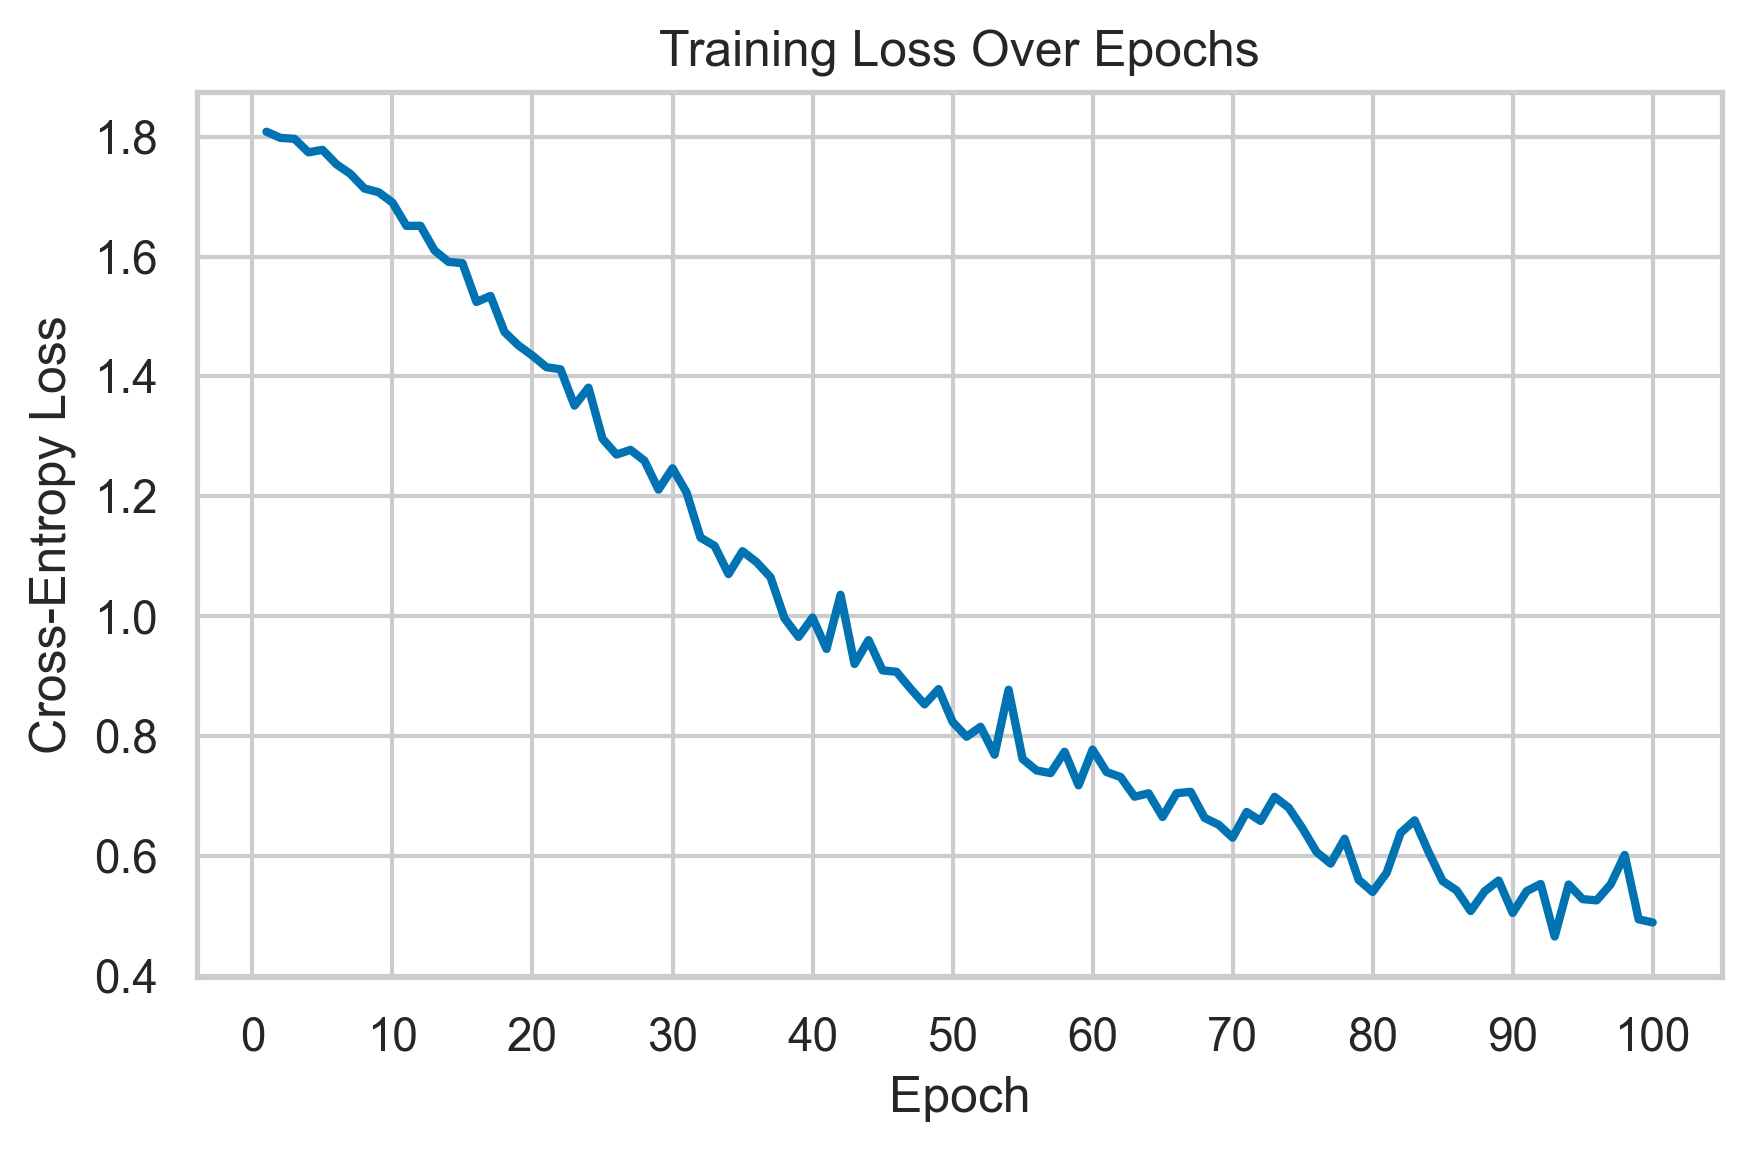

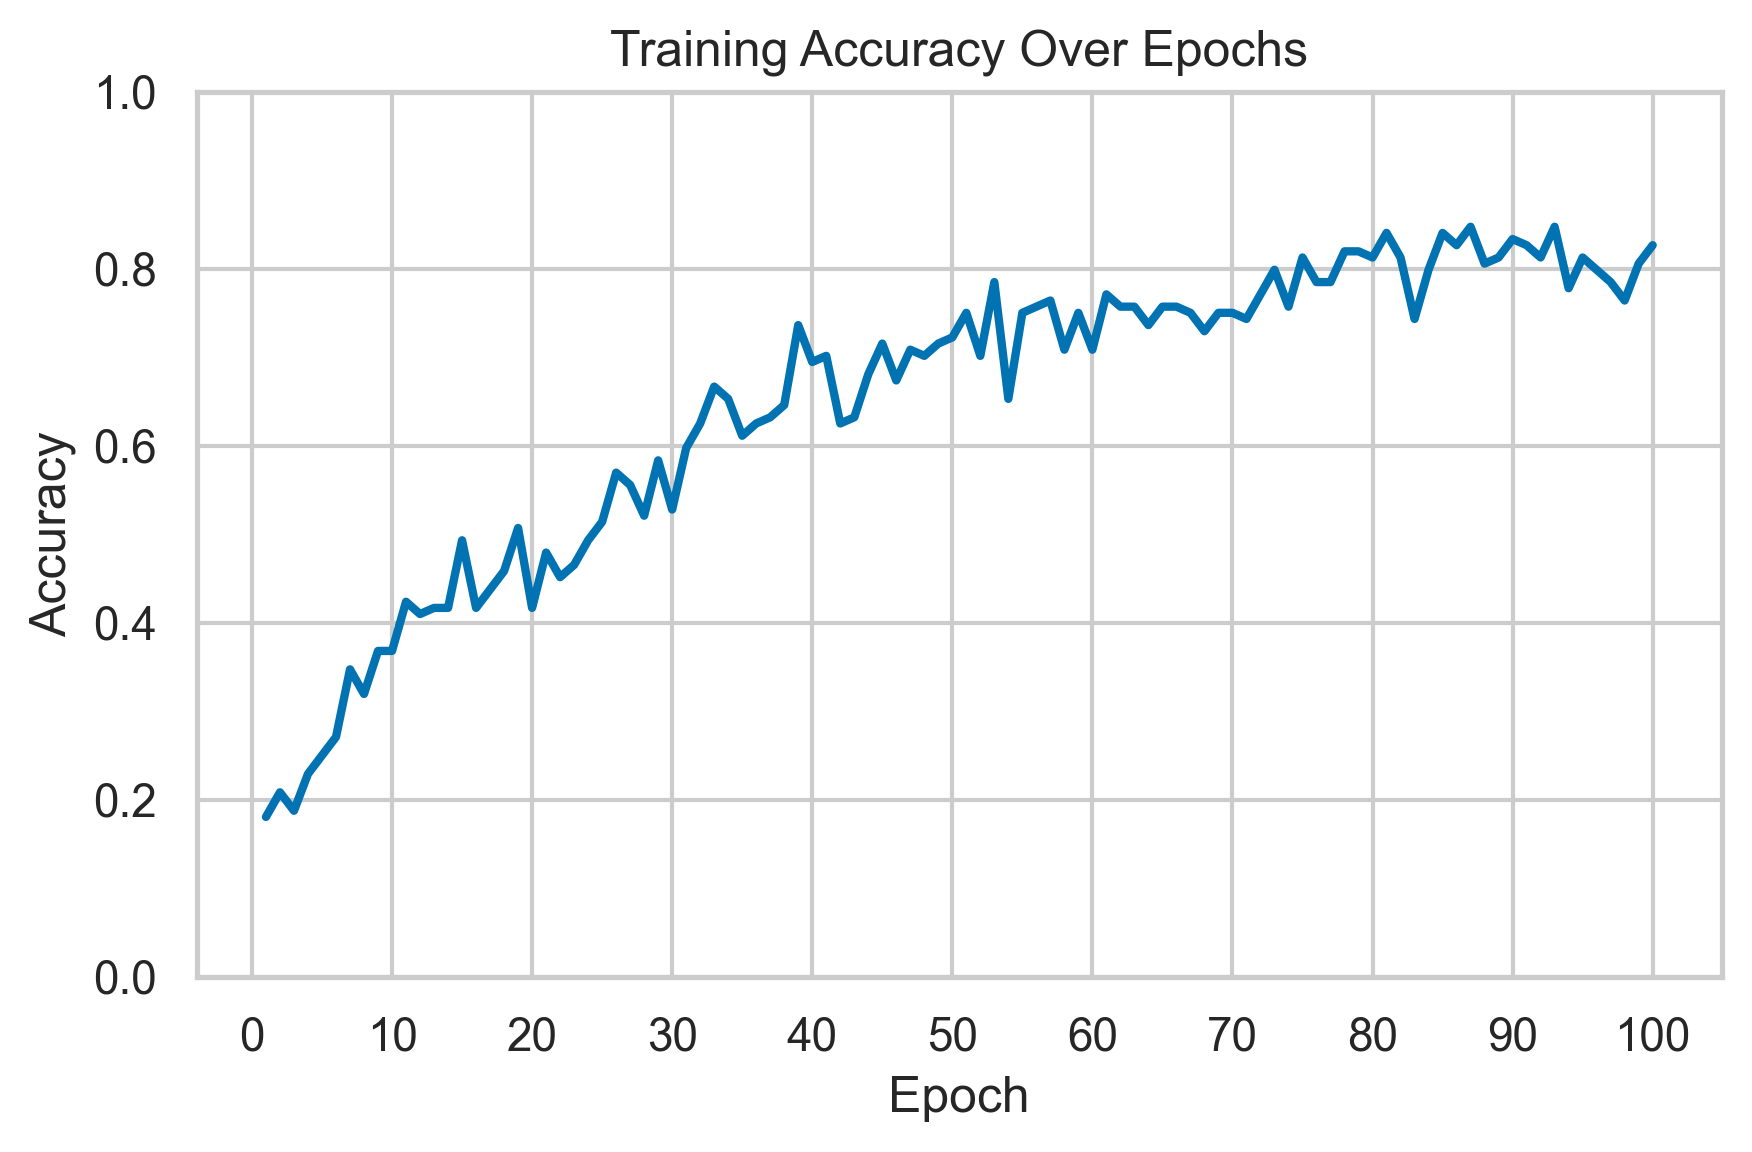

In [16]:
# Training Loss Curve
plt.figure()
plt.plot(range(1, len(loss_history)+1), loss_history, linewidth=2)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.xticks(
    ticks=range(0, len(loss_history)+1, max(1, len(loss_history)//10))
)
plt.tight_layout()
plt.savefig("results/training_loss.png", bbox_inches="tight")
plt.show()

# Training Accuracy Curve
plt.figure()
plt.plot(range(1, len(acc_history)+1), acc_history, linewidth=2)
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.xticks(
    ticks=range(0, len(acc_history)+1, max(1, len(acc_history)//10))
)
plt.tight_layout()
plt.savefig("results/training_accuracy.png", bbox_inches="tight")
plt.show()


# Test Accuracy

In [17]:
model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_true = []

with torch.no_grad():
    for points, labels in test_loader:
        points = points.to(device)
        labels = labels.to(device)

        logits = model(points)
        preds = torch.argmax(logits, dim=1)

        # Accumulate accuracy
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        # Store predictions for confusion matrix & per-class accuracy
        all_preds.extend(preds.cpu().tolist())
        all_true.extend(labels.cpu().tolist())

# Final Test Accuracy
test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 1.0000


# Confusion Matrix

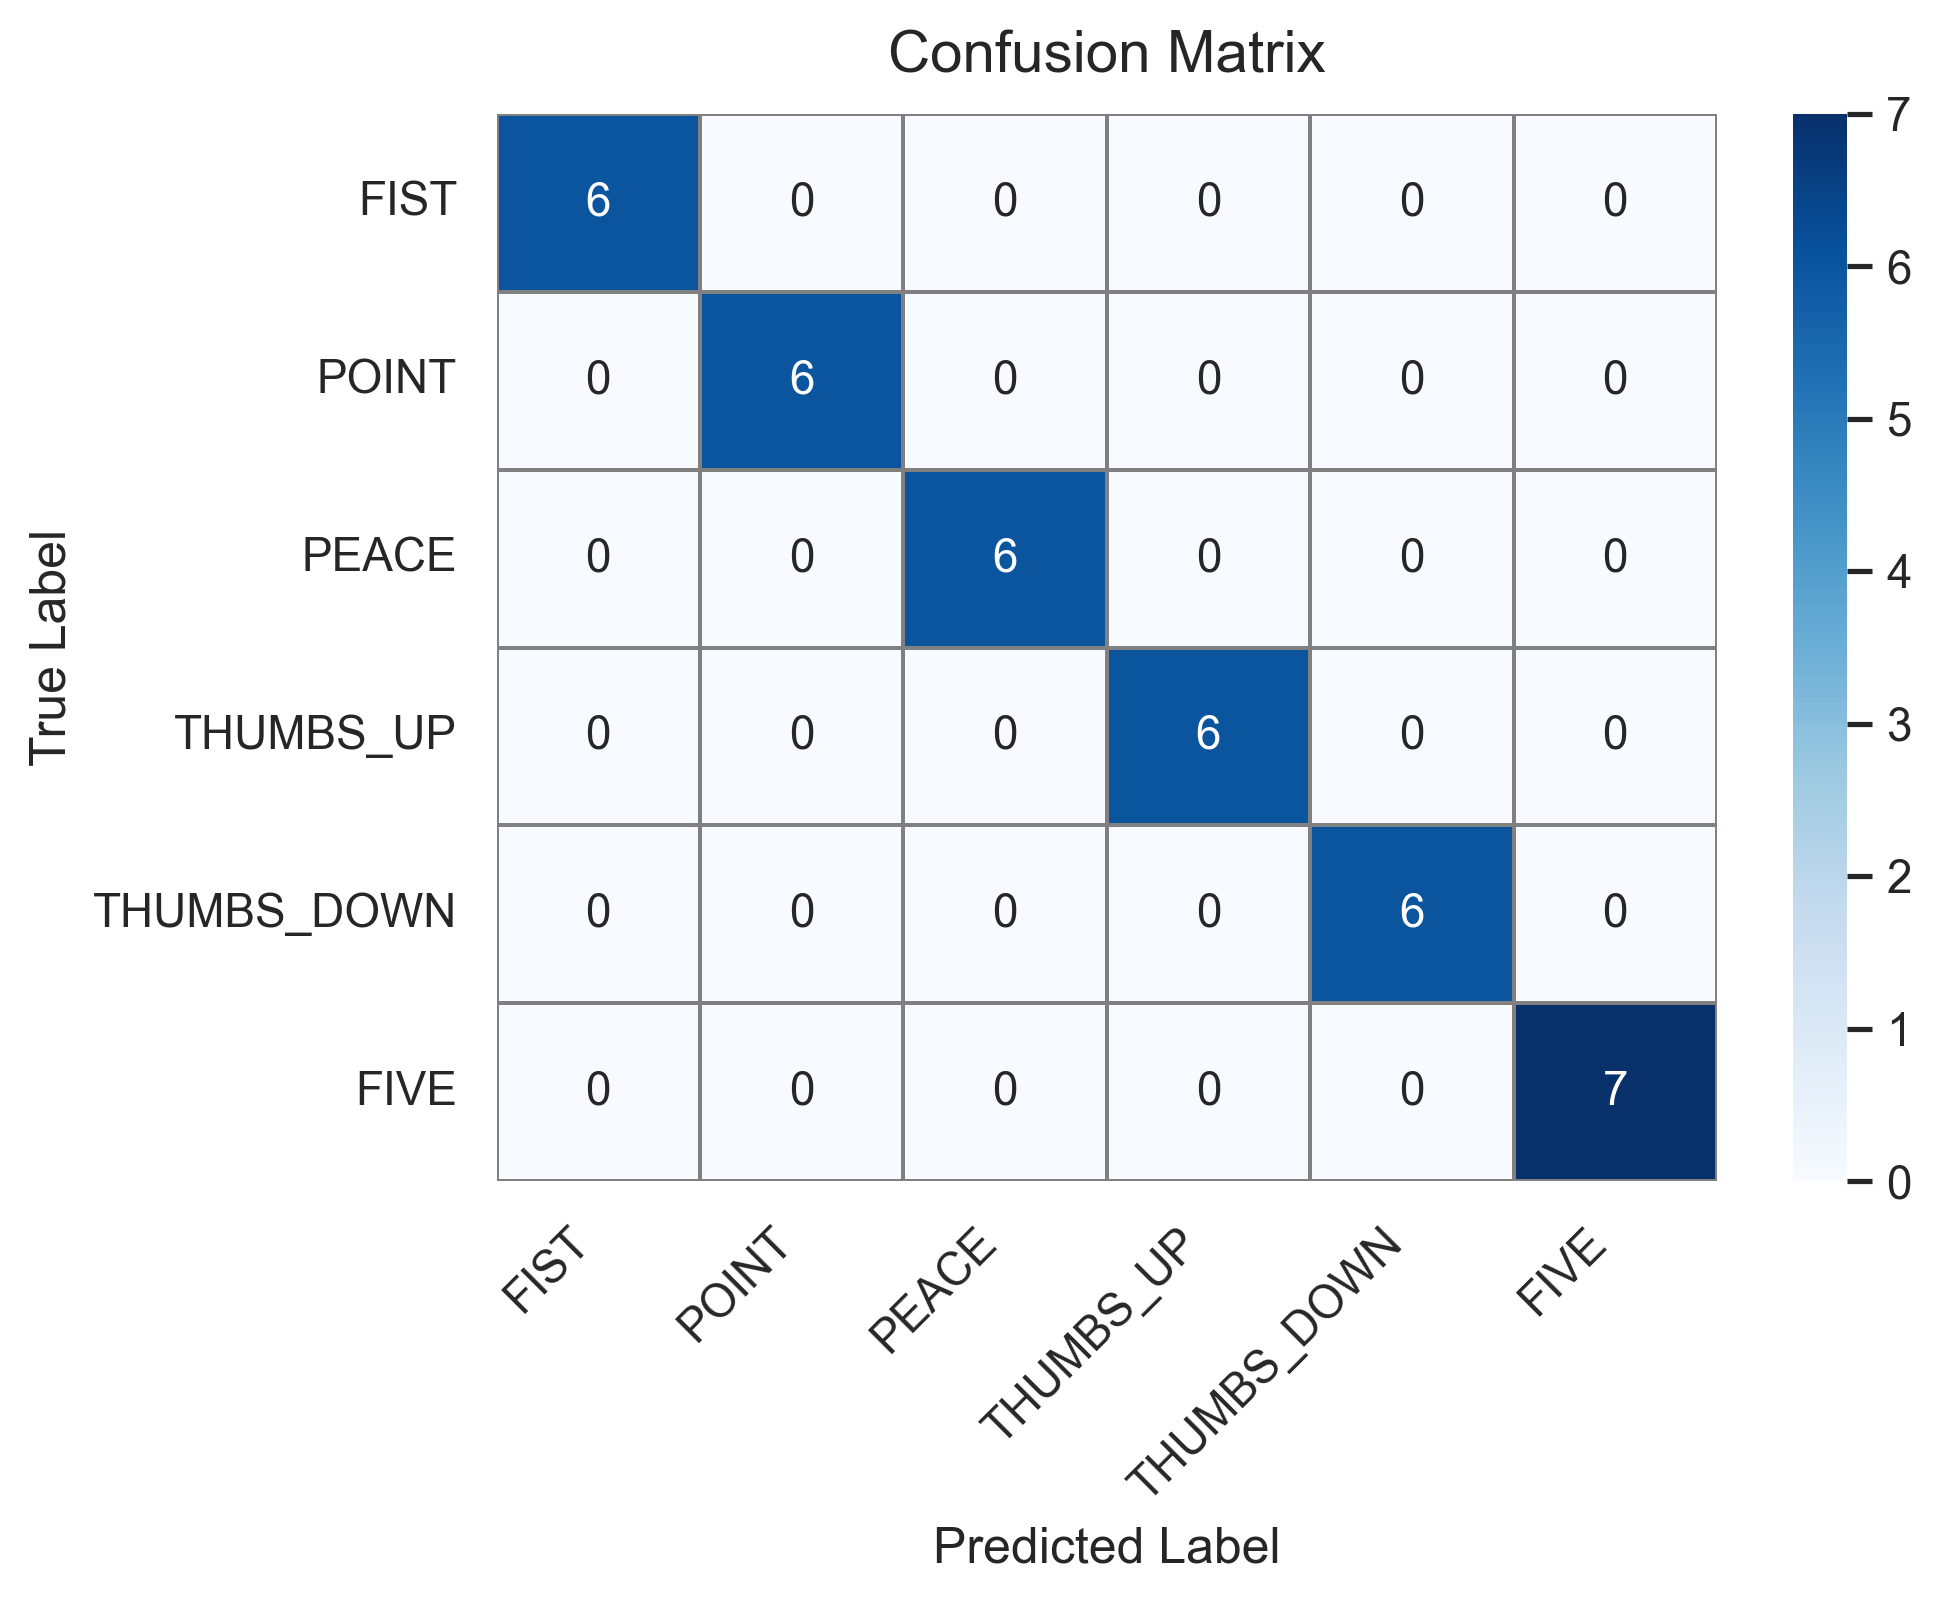

In [18]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(7, 5.5)) # CVPR-appropriate aspect ratio

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
    annot_kws={"size": 11},
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Confusion Matrix", fontsize=14, pad=10)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("results/confusion_matrix.png", bbox_inches="tight", dpi=300)
plt.show()

# Per-class Accuracy Bar Chart

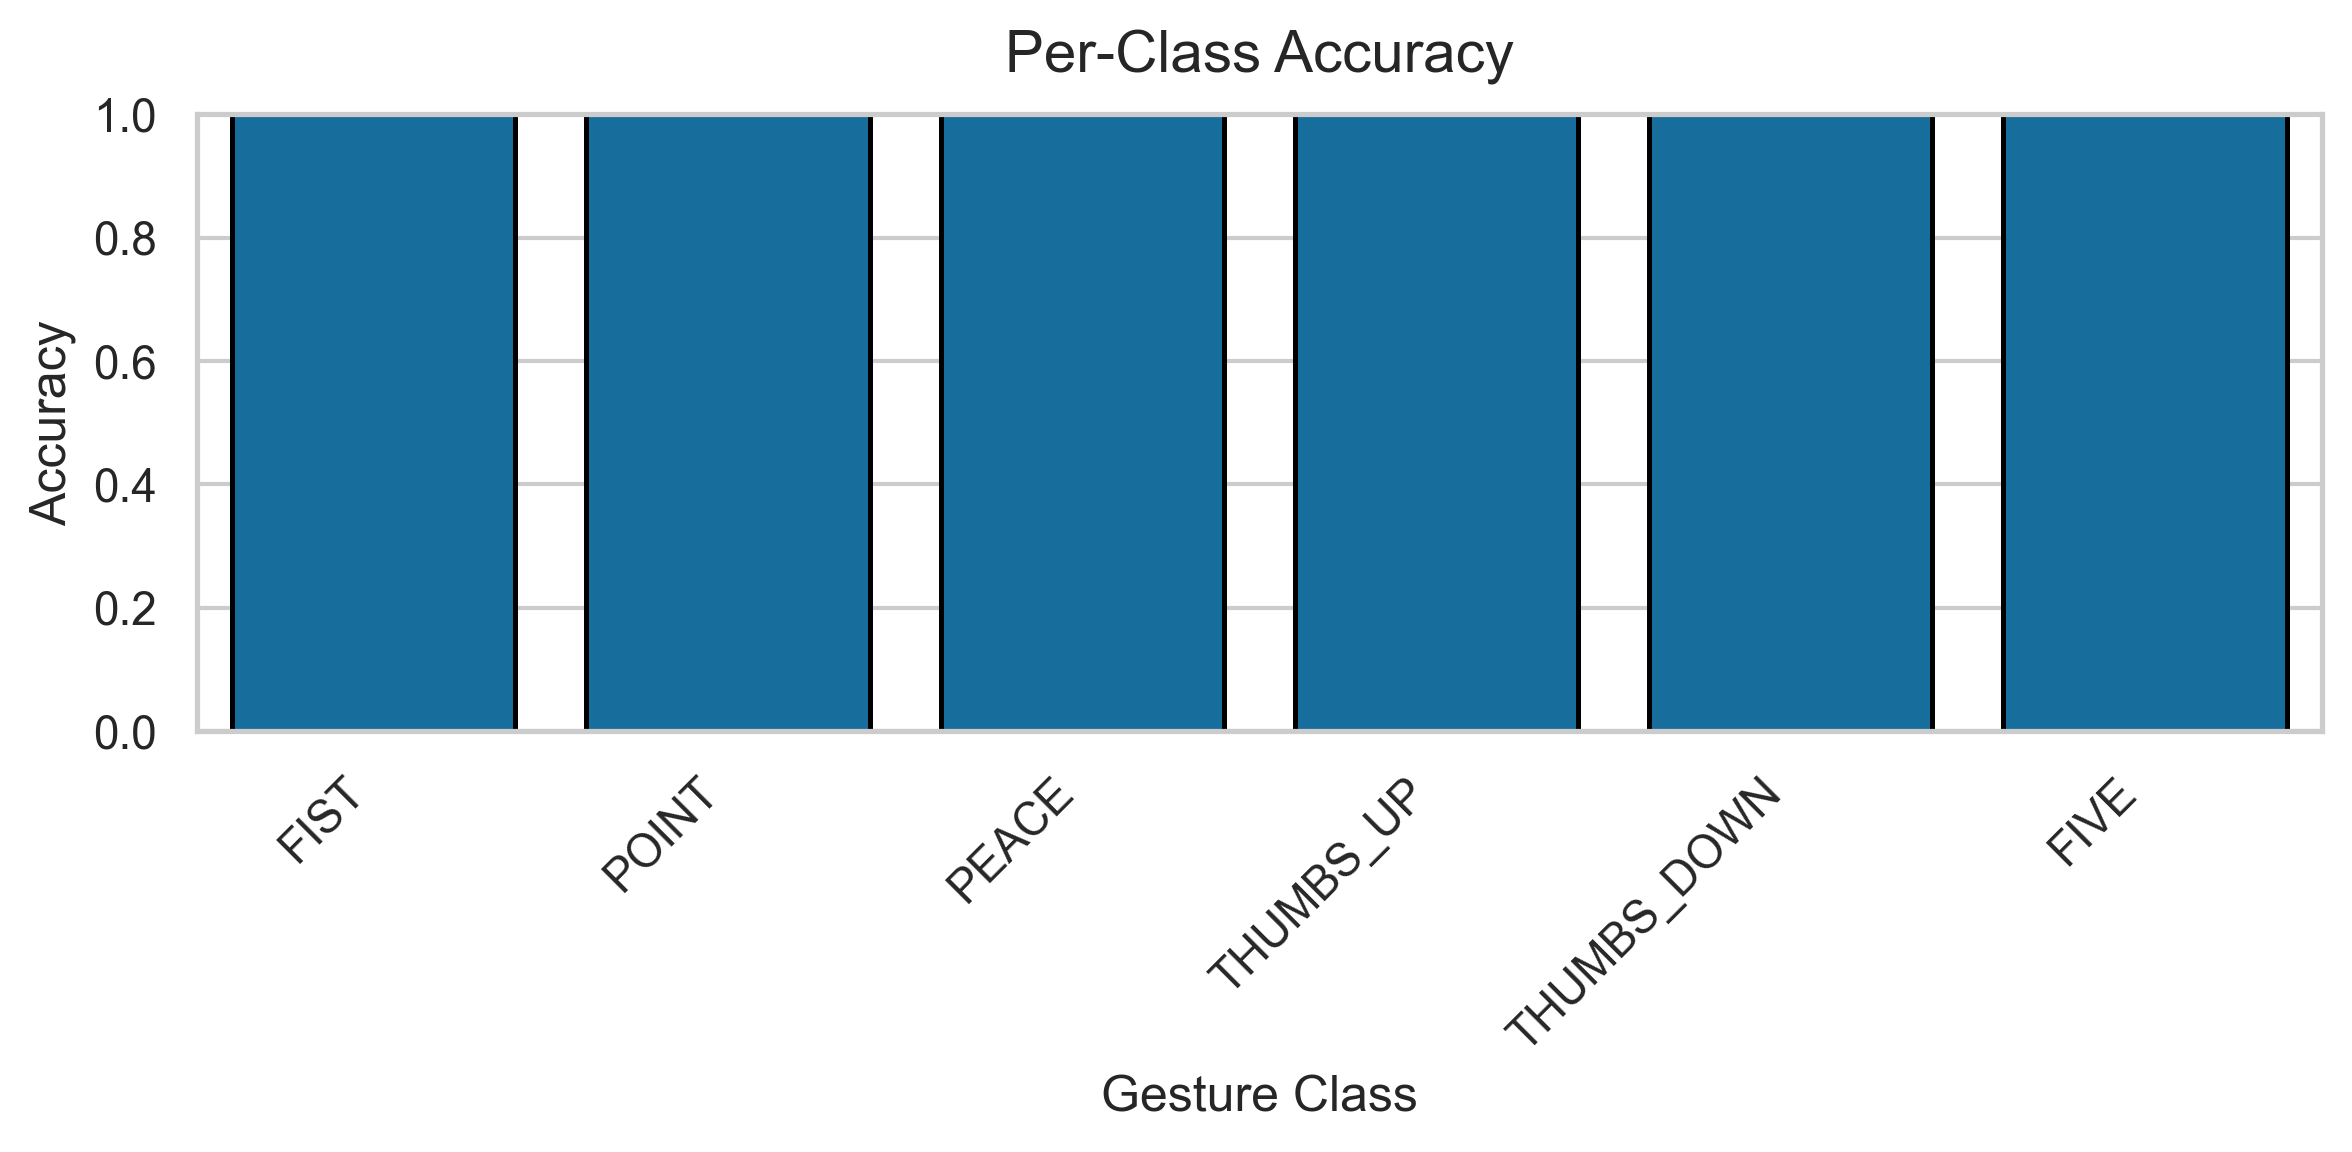

FIST                : 1.000
POINT               : 1.000
PEACE               : 1.000
THUMBS_UP           : 1.000
THUMBS_DOWN         : 1.000
FIVE                : 1.000


In [19]:
num_classes = NUM_CLASSES
correct_per_class = np.zeros(num_classes)
total_per_class = np.zeros(num_classes)

for true, pred in zip(all_true, all_preds):
    if true == pred:
        correct_per_class[true] += 1
    total_per_class[true] += 1

# Handle any case where a class never appears in the test set
class_accuracy = np.divide(
    correct_per_class, 
    total_per_class, 
    out=np.zeros_like(correct_per_class, dtype=float), 
    where=total_per_class != 0
)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=class_names,
    y=class_accuracy,
    edgecolor="black",
    linewidth=1.2
)

plt.title("Per-Class Accuracy", fontsize=14, pad=10)
plt.xlabel("Gesture Class", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.0)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("results/per_class_accuracy.png", bbox_inches="tight", dpi=300)
plt.show()

for name, acc in zip(class_names, class_accuracy):
    print(f"{name:20s}: {acc:.3f}")
